Dataset Loaded Successfully!
Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Unique values in 'Survived' (0 = No, 1 = Yes):
Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\Hp\AppData\Local\Temp\ipykernel_14284\2129758128.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


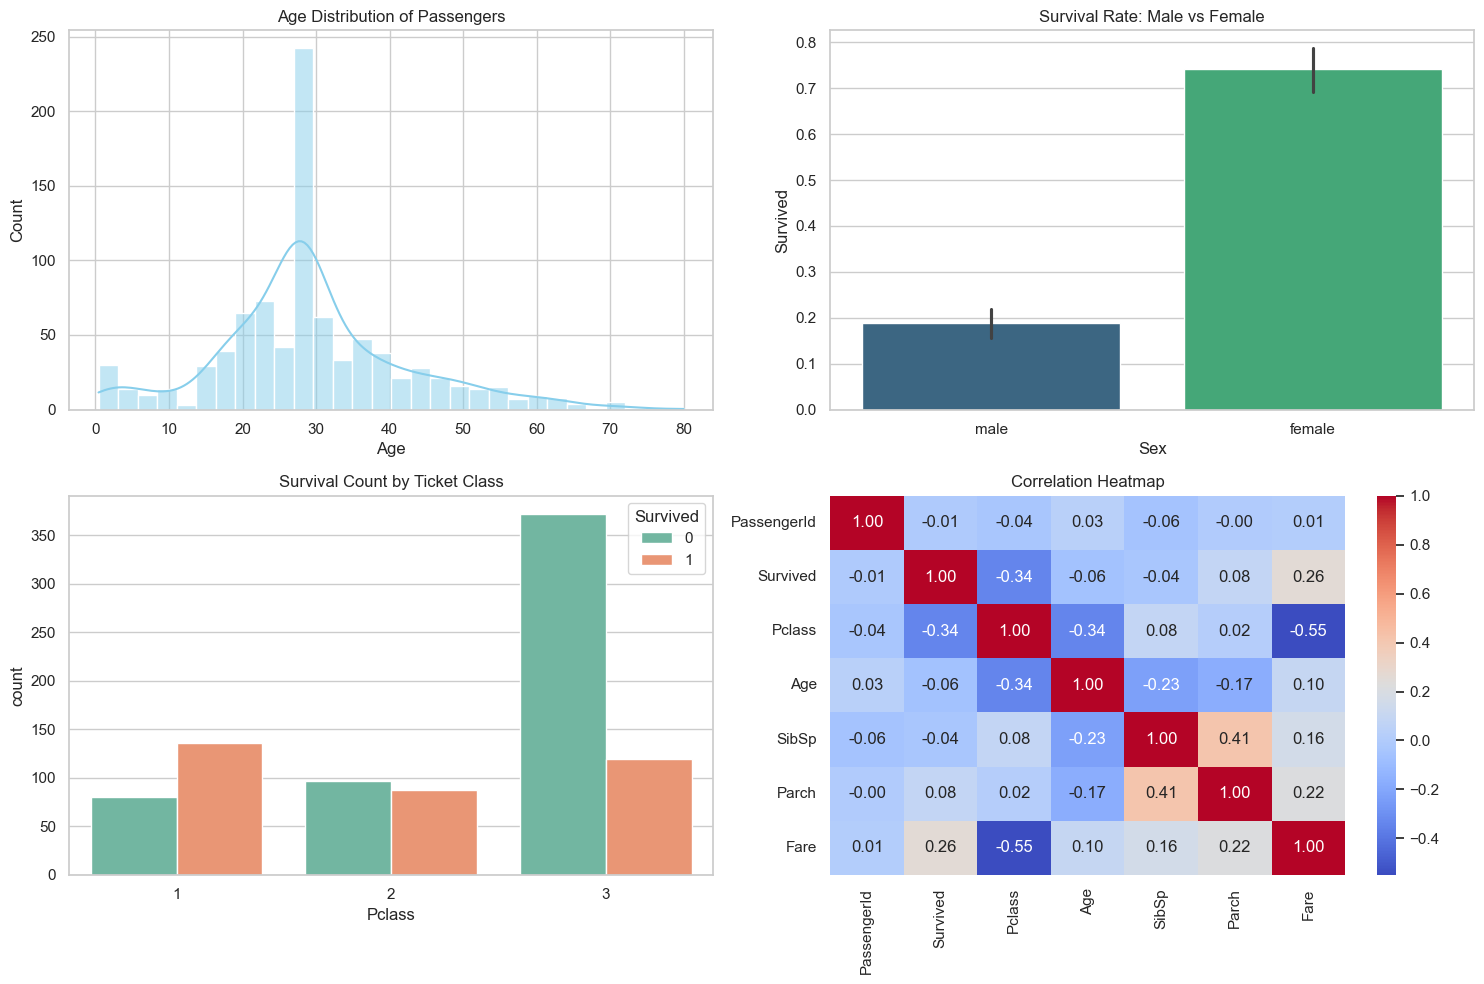

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


print("Dataset Loaded Successfully!")
df.head()



print("Missing values per column:")
print(df.isnull().sum())


df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df.drop(columns=['Cabin'], inplace=True)


print("\nMissing values after cleaning:")
print(df.isnull().sum())


print("Statistical Summary:")
display(df.describe())


print("\nUnique values in 'Survived' (0 = No, 1 = Yes):")
print(df['Survived'].value_counts())



plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')


plt.subplot(2, 2, 2)
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate: Male vs Female')


plt.subplot(2, 2, 3)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Survival Count by Ticket Class')


plt.subplot(2, 2, 4)

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()